# Atlet Toparlanma Skoru Tahmini — Uçtan Uca Veri Bilimi Projesi (Regresyon)

**Veri kaynağı:** [Athlete Recovery & Biometric Performance Dataset (Kaggle)](https://www.kaggle.com/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset)

Sentetik fakat gerçekçi bir longitudinal veri: **~300 atlet × 28 gün** boyunca antrenman, biyometri ve yaşam tarzı kayıtları. Hedef `Recovery_Score` (0–100) **sürekli** bir değişken olduğundan görev **regresyon**.

Bu notebook şu adımları tek akışta uygular:
1. Veri yükleme (yerel CSV → kagglehub → örnek üret),
2. Veri kalitesi ve eksik değer analizi,
3. Hedef ve değişken EDA'sı,
4. Train / val / test ayrımı (athlete-bazlı opsiyon),
5. Özellik mühendisliği (Training_Load, Sleep_Deficit, lag/rolling),
6. Preprocessing pipeline (impute + scale + one-hot),
7. Çoklu regresyon modeli karşılaştırması,
8. Çapraz doğrulama, RandomizedSearchCV ile hiperparametre ayarı,
9. Test değerlendirmesi, artık (residual) analizi, feature importance,
10. Model kaydetme ve örnek tahmin.

**Veri dosyası:** Aşağıdaki adlardan biriyle proje klasörüne CSV koyun: `athlete_recovery_synthetic.csv` (veya `athlete_recovery.csv`, `data.csv`). Yoksa `kagglehub` ile indirme denenir; o da olmazsa örnek veri üretilir.

## 1) Kurulum ve kütüphaneler

In [1]:
import warnings
import os
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split, cross_val_score, RandomizedSearchCV, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
print("Hazir. random_state =", RANDOM_STATE)

Hazir. random_state = 42


## 2) Veri yükleme (yerel CSV → kagglehub → örnek)

In [2]:
LOCAL_NAMES = [
    "athlete_recovery_synthetic.csv",
    "athlete_recovery.csv",
    "Athlete_Recovery.csv",
    "data.csv",
]

def resolve_csv():
    root = Path(".").resolve()
    for name in LOCAL_NAMES:
        p = root / name
        if p.exists():
            return p
    try:
        import kagglehub
        dl = Path(kagglehub.dataset_download("sarveshchhetri/athlete-recovery-and-biometric-performance-dataset"))
        csvs = list(dl.rglob("*.csv"))
        if csvs:
            return max(csvs, key=lambda x: x.stat().st_size)
    except Exception as e:
        print("kagglehub indirme atlandi:", type(e).__name__, str(e)[:120])
    return None


def make_sample_data(n_athletes: int = 60, days: int = 28, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    sports = ["Team Sport", "Endurance", "Strength", "Combat", "Mixed"]
    trainings = ["HIIT", "Cardio", "Yoga", "Strength", "Rest"]
    genders = ["Male", "Female", "Non-binary"]
    stress_levels = ["Low", "Medium", "High"]
    for ath in range(n_athletes):
        age = int(rng.integers(18, 38))
        gender = rng.choice(genders, p=[0.55, 0.42, 0.03])
        sport = rng.choice(sports)
        for d in range(1, days + 1):
            tr_type = rng.choice(trainings, p=[0.2, 0.25, 0.15, 0.2, 0.2])
            dur = 0 if tr_type == "Rest" else int(rng.integers(20, 120))
            intensity = 0.0 if tr_type == "Rest" else float(np.round(rng.uniform(2, 10), 1))
            sleep = float(np.round(rng.normal(7, 1.2), 2))
            caffeine = int(max(0, rng.normal(150, 80)))
            stress = rng.choice(stress_levels, p=[0.35, 0.45, 0.2])
            rhr = int(np.clip(rng.normal(62, 8) + (intensity * 0.5), 40, 110))
            hrv = int(np.clip(rng.normal(70, 18) - (intensity * 1.2), 20, 140))
            mood = float(np.round(rng.uniform(1, 10), 1))
            sore = float(np.round(np.clip(rng.normal(intensity * 0.6, 1.5), 0, 10), 1))
            energy = float(np.round(np.clip(10 - sore + rng.normal(0, 1.2), 1, 10), 1))
            # Recovery_Score sentetik formul (gercege benzer karisik etki)
            recovery = (
                50
                + 4.0 * (sleep - 7)
                + 0.15 * (hrv - 70)
                - 0.4 * (rhr - 62)
                - 2.0 * intensity * (dur / 60)
                - 1.5 * (1 if stress == "High" else (0.6 if stress == "Medium" else 0))
                + 1.2 * (mood - 5)
                - 1.8 * sore
                + 1.0 * (energy - 5)
                + rng.normal(0, 4)
            )
            recovery = float(np.clip(np.round(recovery, 1), 0, 100))
            rows.append({
                "Athlete_ID": 1000 + ath,
                "Day": d,
                "Day_of_Week": ((d - 1) % 7) + 1,
                "Week": ((d - 1) // 7) + 1,
                "Age": age,
                "Gender": gender,
                "Sport_Type": sport,
                "Training_Type": tr_type,
                "Training_Duration_Min": dur,
                "Training_Intensity": intensity,
                "Sleep_Duration_Hours": sleep,
                "Caffeine_Intake_mg": caffeine,
                "Stress_Level": stress,
                "Resting_Heart_Rate": rhr,
                "HRV_ms": hrv,
                "Mood_Score": mood,
                "Muscle_Soreness": sore,
                "Energy_Level": energy,
                "Recovery_Score": recovery,
            })
    out = pd.DataFrame(rows)
    # Az miktarda eksik veri ekle (gercek veri ile uyumlu olmasi icin)
    miss_idx = rng.choice(out.index, size=int(len(out) * 0.07), replace=False)
    out.loc[miss_idx, "Sleep_Duration_Hours"] = np.nan
    return out


path = resolve_csv()
if path is not None:
    df = pd.read_csv(path)
    print("Veri dosyasi:", path)
else:
    print("Yerel CSV / kagglehub yok; ornek veri uretiliyor (gercek analiz icin Kaggle CSV yukleyin).")
    df = make_sample_data()

print("Boyut:", df.shape)
df.head()

Veri dosyasi: C:\Users\Administrator\Desktop\Marmara_YL\Python_data_analysis\athlete_recovery_synthetic.csv
Boyut: (8379, 19)


,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3


## 3) Hedef ve sütun tanımı

In [3]:
TARGET = "Recovery_Score"
GROUP_COL = "Athlete_ID" if "Athlete_ID" in df.columns else None
ID_LIKE = {"athlete_id", "id", "index", "unnamed: 0"}

assert TARGET in df.columns, f"Hedef sutun '{TARGET}' bulunamadi."

print("Hedef:", TARGET)
print("Hedef ozet:")
print(df[TARGET].describe())
print("\nAtlet sayisi:", df[GROUP_COL].nunique() if GROUP_COL else "N/A")
print("Toplam gun gozlemi:", len(df))

Hedef: Recovery_Score
Hedef ozet:
count    8379.000000
mean       49.061356
std        27.926347
min         0.000000
25%        27.800000
50%        48.900000
75%        69.900000
max       100.000000
Name: Recovery_Score, dtype: float64

Atlet sayisi: 300
Toplam gun gozlemi: 8379


## 4) Veri kalitesi

In [4]:
df.info()
print("\nEksik deger (sirali):")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print("\nTekrar satir:", df.duplicated().sum())
print("\nKategorik sutun benzersizleri:")
for c in df.select_dtypes(include="object").columns:
    print(f"  {c}: {sorted(df[c].dropna().unique().tolist())[:10]}")

<class 'pandas.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete_ID             8379 non-null   int64  
 1   Day                    8379 non-null   int64  
 2   Day_of_Week            8379 non-null   int64  
 3   Week                   8379 non-null   int64  
 4   Age                    8379 non-null   int64  
 5   Gender                 8379 non-null   str    
 6   Sport_Type             8379 non-null   str    
 7   Training_Type          8379 non-null   str    
 8   Training_Duration_Min  8379 non-null   int64  
 9   Training_Intensity     8378 non-null   float64
 10  Sleep_Duration_Hours   7775 non-null   float64
 11  Caffeine_Intake_mg     8379 non-null   int64  
 12  Stress_Level           8379 non-null   str    
 13  Resting_Heart_Rate     8379 non-null   int64  
 14  HRV_ms                 8379 non-null   int64  
 15  Mood_Score     

## 5) Hedef dağılımı

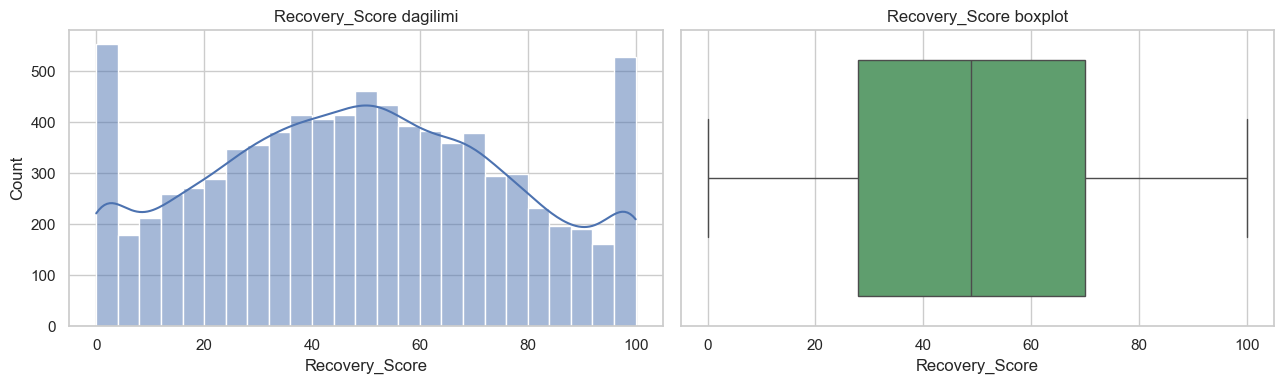

Skewness: 0.043
Kurtosis: -0.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET].dropna(), kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"{TARGET} dagilimi")
sns.boxplot(x=df[TARGET].dropna(), ax=axes[1], color="#55A868")
axes[1].set_title(f"{TARGET} boxplot")
plt.tight_layout()
plt.show()

print("Skewness:", round(df[TARGET].skew(), 3))
print("Kurtosis:", round(df[TARGET].kurt(), 3))

## 6) Sayısal değişkenlerin hedefle ilişkisi (korelasyon)

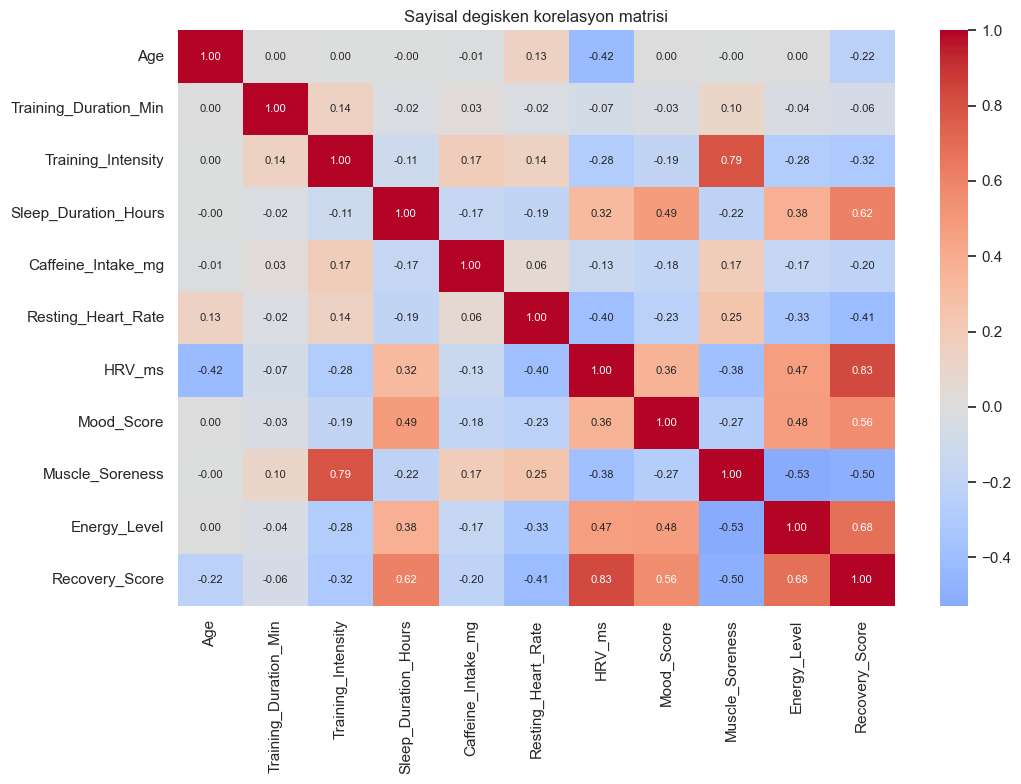

Hedefle korelasyonlar (|r| sirali):
HRV_ms                   0.828
Energy_Level             0.682
Sleep_Duration_Hours     0.616
Mood_Score               0.559
Muscle_Soreness         -0.502
Resting_Heart_Rate      -0.413
Training_Intensity      -0.318
Age                     -0.225
Caffeine_Intake_mg      -0.201
Training_Duration_Min   -0.065
Name: Recovery_Score, dtype: float64


In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in {"Day", "Day_of_Week", "Week", "Athlete_ID"}]

plt.figure(figsize=(11, 8))
sns.heatmap(df[num_cols].corr(numeric_only=True), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Sayisal degisken korelasyon matrisi")
plt.tight_layout()
plt.show()

corr_with_target = df[num_cols].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
print("Hedefle korelasyonlar (|r| sirali):")
print(corr_with_target.round(3))

## 7) Kategorik değişkenlerin hedefe etkisi

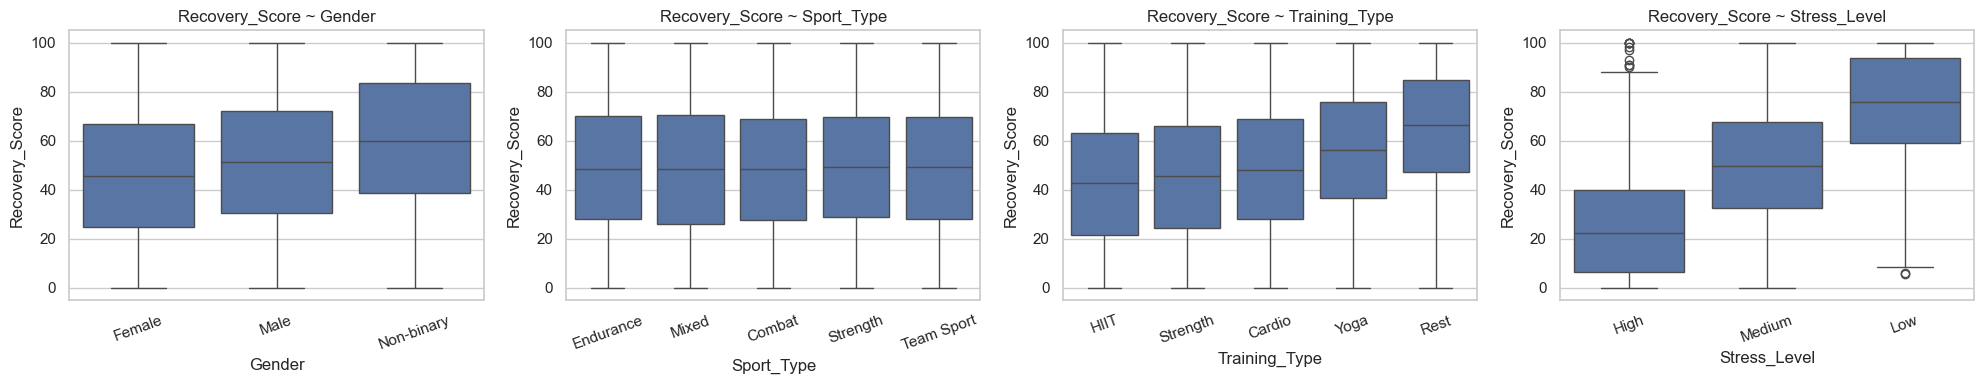


Gender bazinda ortalama Recovery_Score:
             mean  median  count
Gender                          
Non-binary  59.82    59.8    252
Male        51.49    51.4   3936
Female      46.13    45.7   4191

Sport_Type bazinda ortalama Recovery_Score:
             mean  median  count
Sport_Type                      
Team Sport  49.51   49.50   2799
Strength    49.25   49.15   1476
Mixed       48.82   48.60   1256
Combat      48.69   48.70    921
Endurance   48.59   48.30   1927

Training_Type bazinda ortalama Recovery_Score:
                mean  median  count
Training_Type                      
Rest           64.67    66.6    929
Yoga           56.43    56.4    716
Cardio         48.52    48.2   2270
Strength       46.22    45.8   2237
HIIT           43.59    42.7   2227

Stress_Level bazinda ortalama Recovery_Score:
               mean  median  count
Stress_Level                      
Low           73.62   75.85   1650
Medium        50.22   49.90   4806
High          25.09   22.50   1

In [7]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    n = len(cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, c in zip(axes, cat_cols):
        order = df.groupby(c)[TARGET].median().sort_values().index
        sns.boxplot(data=df, x=c, y=TARGET, ax=ax, order=order)
        ax.set_title(f"{TARGET} ~ {c}")
        ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    for c in cat_cols:
        print(f"\n{c} bazinda ortalama {TARGET}:")
        print(df.groupby(c)[TARGET].agg(["mean", "median", "count"]).round(2).sort_values("mean", ascending=False))

## 8) Atletler arası ve haftalar arası örüntü

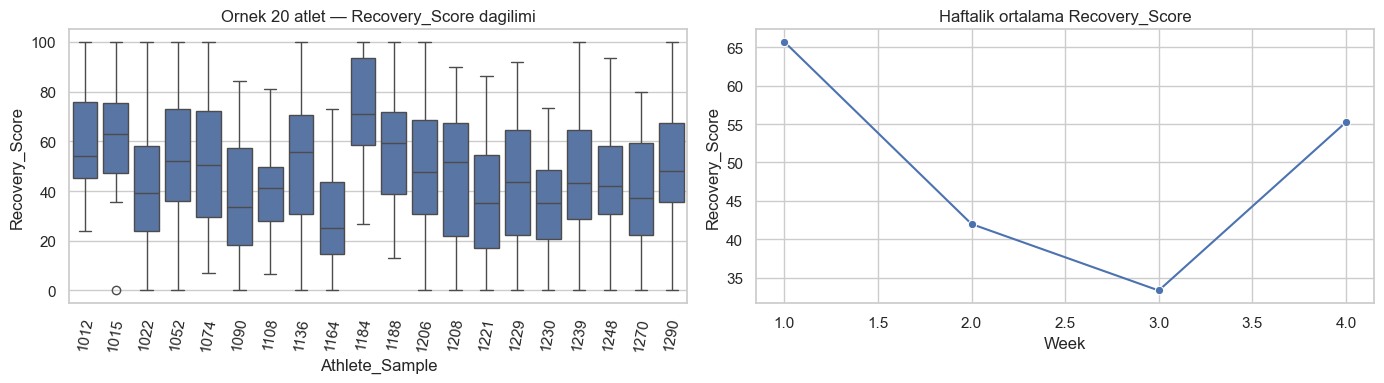

In [8]:
if GROUP_COL is not None:
    n_sample = min(20, df[GROUP_COL].nunique())
    sampled_ids = pd.Series(df[GROUP_COL].unique()).sample(n_sample, random_state=0).tolist()
    sub = df[df[GROUP_COL].isin(sampled_ids)].copy()
    sub["Athlete_Sample"] = sub[GROUP_COL].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=sub, x="Athlete_Sample", y=TARGET, ax=axes[0])
    axes[0].set_title(f"Ornek {n_sample} atlet — Recovery_Score dagilimi")
    axes[0].tick_params(axis="x", rotation=80)

    if "Week" in df.columns:
        weekly = df.groupby("Week")[TARGET].mean().reset_index()
        sns.lineplot(data=weekly, x="Week", y=TARGET, marker="o", ax=axes[1])
        axes[1].set_title("Haftalik ortalama Recovery_Score")
    else:
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

## 9) Train / val / test ayrımı (atlet bazlı opsiyonel)

In [9]:
# Athlete-bazli split: ayni atletin farkli gunleri ayni split icinde kalir → veri sizintisini azaltir.
SPLIT_MODE = "athlete"  # "random" yapilirsa rastgele satir bazli olur.

feat_cols = [c for c in df.columns if c not in {TARGET, GROUP_COL}]
X_all = df[feat_cols].copy()
y_all = df[TARGET].astype(float).copy()

if SPLIT_MODE == "athlete" and GROUP_COL is not None:
    groups = df[GROUP_COL].values
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
    tv_idx, te_idx = next(gss1.split(X_all, y_all, groups))
    X_tv, X_test = X_all.iloc[tv_idx], X_all.iloc[te_idx]
    y_tv, y_test = y_all.iloc[tv_idx], y_all.iloc[te_idx]
    groups_tv = groups[tv_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=RANDOM_STATE)
    tr_idx, va_idx = next(gss2.split(X_tv, y_tv, groups_tv))
    X_train, X_val = X_tv.iloc[tr_idx], X_tv.iloc[va_idx]
    y_train, y_val = y_tv.iloc[tr_idx], y_tv.iloc[va_idx]
else:
    X_tv, X_test, y_tv, y_test = train_test_split(X_all, y_all, test_size=0.15, random_state=RANDOM_STATE)
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.1765, random_state=RANDOM_STATE)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
if GROUP_COL is not None and SPLIT_MODE == "athlete":
    tr_g = set(df.loc[X_train.index, GROUP_COL].unique())
    va_g = set(df.loc[X_val.index, GROUP_COL].unique())
    te_g = set(df.loc[X_test.index, GROUP_COL].unique())
    print("Train atlet:", len(tr_g), "| Val atlet:", len(va_g), "| Test atlet:", len(te_g))
    print("Kesisim (train∩test):", len(tr_g & te_g))

Train: 5840 | Val: 1284 | Test: 1255
Train atlet: 209 | Val atlet: 46 | Test atlet: 45
Kesisim (train∩test): 0


## 10) Özellik mühendisliği

In [10]:
def add_features(din: pd.DataFrame) -> pd.DataFrame:
    d = din.copy()
    # Antrenman yuku = Sure (saat) x Yogunluk
    if "Training_Duration_Min" in d.columns and "Training_Intensity" in d.columns:
        d["Training_Load"] = (d["Training_Duration_Min"].fillna(0) / 60.0) * d["Training_Intensity"].fillna(0)
    # Uyku acigi (8 saate gore)
    if "Sleep_Duration_Hours" in d.columns:
        d["Sleep_Deficit"] = (8.0 - d["Sleep_Duration_Hours"]).clip(lower=0)
    # HRV / RHR orani (otonom denge proxy'si)
    if "HRV_ms" in d.columns and "Resting_Heart_Rate" in d.columns:
        d["HRV_RHR_Ratio"] = d["HRV_ms"] / d["Resting_Heart_Rate"].replace(0, np.nan)
    # Hafta ici / hafta sonu
    if "Day_of_Week" in d.columns:
        d["Is_Weekend"] = (d["Day_of_Week"] >= 6).astype(int)
    return d


X_train_fe = add_features(X_train)
X_val_fe = add_features(X_val)
X_test_fe = add_features(X_test)

print("Yeni sutunlar:")
print([c for c in X_train_fe.columns if c not in X_train.columns])
X_train_fe.head()

Yeni sutunlar:
['Training_Load', 'Sleep_Deficit', 'HRV_RHR_Ratio', 'Is_Weekend']


,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Training_Load,Sleep_Deficit,HRV_RHR_Ratio,Is_Weekend
0,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,6.056667,0.3,1.271186,0
1,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,8.283333,0.7,1.436364,0
2,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,5.475000,0.3,1.350877,0
3,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,10.750000,0.1,1.163934,0
4,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,4.293333,1.3,0.968750,0


## 11) Preprocessing pipeline

In [11]:
def make_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_features = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X_train_fe.columns if c not in num_features]
print("Sayisal:", num_features)
print("Kategorik:", cat_features)

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_features),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", make_onehot())]), cat_features),
    ]
)


def build_reg(model):
    return Pipeline([("pre", pre), ("model", model)])

Sayisal: ['Day', 'Day_of_Week', 'Week', 'Age', 'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Training_Load', 'Sleep_Deficit', 'HRV_RHR_Ratio', 'Is_Weekend']
Kategorik: ['Gender', 'Sport_Type', 'Training_Type', 'Stress_Level']


## 12) Metrik yardımcıları

In [12]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_reg(reg, Xd, yd):
    pred = reg.predict(Xd)
    return {
        "rmse": rmse(yd, pred),
        "mae": float(mean_absolute_error(yd, pred)),
        "r2": float(r2_score(yd, pred)),
    }

# Naif baseline: train ortalamasi
naive_pred = np.full_like(y_val.values, y_train.mean(), dtype=float)
print("Naif (ortalama) baseline -> val RMSE:", round(rmse(y_val, naive_pred), 3),
      "| MAE:", round(mean_absolute_error(y_val, naive_pred), 3),
      "| R2:", round(r2_score(y_val, naive_pred), 3))

Naif (ortalama) baseline -> val RMSE: 27.83 | MAE: 23.161 | R2: -0.015


## 13) Çoklu model karşılaştırması (validation)

In [13]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=5000),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=300),
}

rows = []
for name, m in models.items():
    pipe = build_reg(m)
    pipe.fit(X_train_fe, y_train)
    tr = evaluate_reg(pipe, X_train_fe, y_train)
    vl = evaluate_reg(pipe, X_val_fe, y_val)
    rows.append({
        "model": name,
        "train_rmse": tr["rmse"], "val_rmse": vl["rmse"],
        "train_mae": tr["mae"], "val_mae": vl["mae"],
        "train_r2": tr["r2"], "val_r2": vl["r2"],
    })

baseline_df = pd.DataFrame(rows).sort_values("val_rmse")
baseline_df

,model,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
5,GradientBoosting,8.183025e+00,8.571949,6.393864e+00,6.775524,0.915251,0.903673
4,ExtraTrees,2.127858e-13,8.654805,1.518426e-13,6.821220,1.000000,0.901802
3,RandomForest,3.396873e+00,8.701520,2.635118e+00,6.809775,0.985396,0.900739
6,HistGradientBoosting,4.262627e+00,8.737816,3.236970e+00,6.853949,0.977003,0.899909
2,Lasso,9.304291e+00,8.954267,7.325140e+00,7.141524,0.890434,0.894889
1,Ridge,9.301670e+00,8.955042,7.323878e+00,7.143377,0.890496,0.894870
0,LinearRegression,9.301648e+00,8.955286,7.324025e+00,7.143536,0.890497,0.894865


## 14) Cross-validation (train+val)

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_full = pd.concat([X_train_fe, X_val_fe], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

best_row = baseline_df.iloc[0]
best_base_name = best_row["model"]
base_estimator = models[best_base_name]
cv_pipe = build_reg(clone(base_estimator))

rmse_cv = cross_val_score(cv_pipe, X_full, y_full, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
r2_cv = cross_val_score(cv_pipe, X_full, y_full, cv=cv, scoring="r2", n_jobs=1)
print("CV secilen model:", best_base_name)
print("CV RMSE mean/std:", round(-rmse_cv.mean(), 4), round(rmse_cv.std(), 4))
print("CV R2 mean/std:", round(r2_cv.mean(), 4), round(r2_cv.std(), 4))

CV secilen model: GradientBoosting
CV RMSE mean/std: 8.8178 0.1315
CV R2 mean/std: 0.9011 0.0027


## 15) Hiperparametre tuning (RandomizedSearchCV)

In [15]:
param_spaces = {
    "LinearRegression": {},
    "Ridge": {"model__alpha": np.logspace(-3, 3, 14)},
    "Lasso": {"model__alpha": np.logspace(-4, 1, 14)},
    "RandomForest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 8, 14, 22],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.6, 1.0],
    },
    "ExtraTrees": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 10, 18, 28],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "GradientBoosting": {
        "model__n_estimators": [150, 250, 400],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
        "model__max_depth": [None, 6, 10, 16],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__min_samples_leaf": [10, 20, 40],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    },
}

space = param_spaces.get(best_base_name, param_spaces["HistGradientBoosting"])
if space:
    tuned = RandomizedSearchCV(
        build_reg(clone(base_estimator)),
        space,
        n_iter=20,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    tuned.fit(X_full, y_full)
    print("En iyi CV RMSE:", round(-tuned.best_score_, 4))
    print("Parametreler:", tuned.best_params_)
    best_model = tuned.best_estimator_
else:
    print("Aranacak parametre uzayi yok; baseline modeli kullaniyoruz.")
    best_model = build_reg(clone(base_estimator))
    best_model.fit(X_full, y_full)

En iyi CV RMSE: 8.7094
Parametreler: {'model__subsample': 0.7, 'model__n_estimators': 250, 'model__max_depth': 5, 'model__learning_rate': 0.03}


## 16) Final test değerlendirmesi

Test metrikleri: {'rmse': 8.7284, 'mae': 6.9577, 'r2': 0.8969}


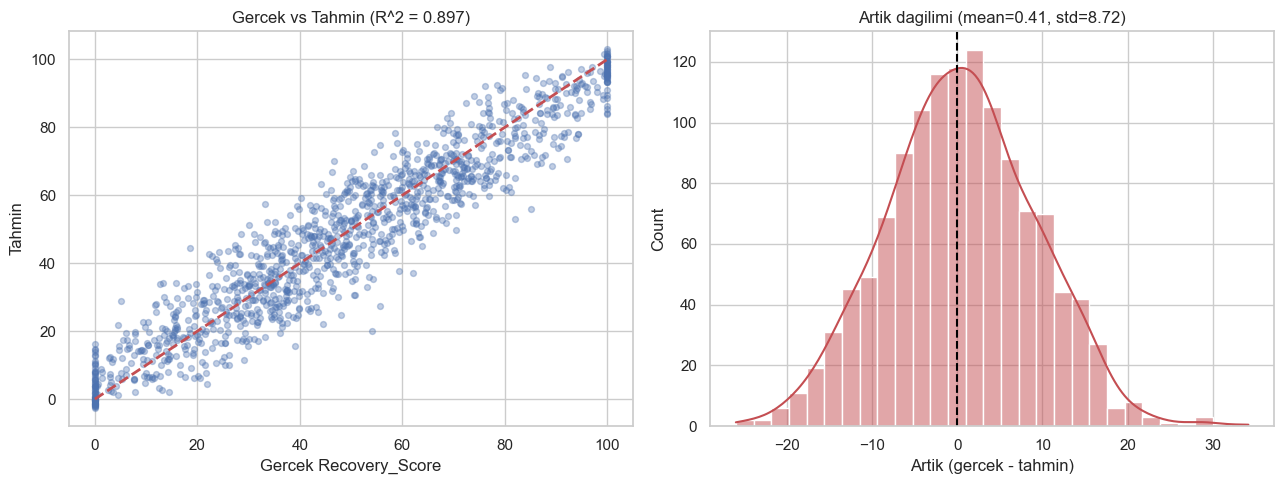

In [16]:
best_model.fit(X_full, y_full)
test_metrics = evaluate_reg(best_model, X_test_fe, y_test)
print("Test metrikleri:", {k: round(v, 4) for k, v in test_metrics.items()})

y_pred_test = best_model.predict(X_test_fe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred_test, alpha=0.35, s=18)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Gercek Recovery_Score")
axes[0].set_ylabel("Tahmin")
axes[0].set_title(f"Gercek vs Tahmin (R^2 = {test_metrics['r2']:.3f})")

residuals = y_test.values - y_pred_test
sns.histplot(residuals, kde=True, ax=axes[1], color="#C44E52")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Artik (gercek - tahmin)")
axes[1].set_title(f"Artik dagilimi (mean={residuals.mean():.2f}, std={residuals.std():.2f})")
plt.tight_layout()
plt.show()

## 17) Özellik önemi (permutation / built-in)

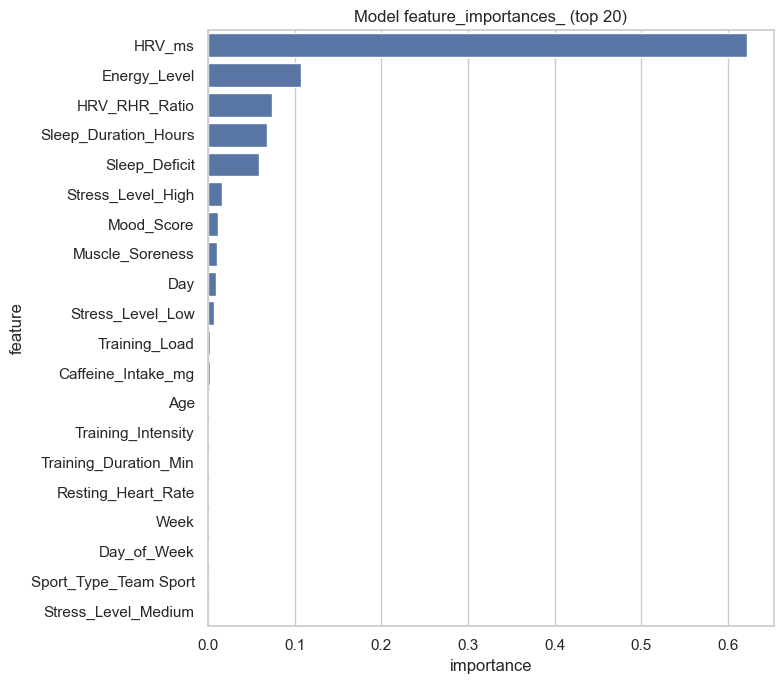

              feature  importance
               HRV_ms      0.6222
         Energy_Level      0.1069
        HRV_RHR_Ratio      0.0744
 Sleep_Duration_Hours      0.0683
        Sleep_Deficit      0.0585
    Stress_Level_High      0.0162
           Mood_Score      0.0114
      Muscle_Soreness      0.0110
                  Day      0.0088
     Stress_Level_Low      0.0073
        Training_Load      0.0026
   Caffeine_Intake_mg      0.0024
                  Age      0.0016
   Training_Intensity      0.0015
Training_Duration_Min      0.0015
   Resting_Heart_Rate      0.0013
                 Week      0.0012
          Day_of_Week      0.0009
Sport_Type_Team Sport      0.0005
  Stress_Level_Medium      0.0003


In [17]:
from sklearn.inspection import permutation_importance

try:
    final_estimator = best_model.named_steps["model"]
    pre_step = best_model.named_steps["pre"]
    feat_names_num = num_features
    try:
        ohe = pre_step.named_transformers_["cat"].named_steps["oh"]
        feat_names_cat = list(ohe.get_feature_names_out(cat_features))
    except Exception:
        feat_names_cat = []
    feat_names = feat_names_num + feat_names_cat
    importances = getattr(final_estimator, "feature_importances_", None)
    if importances is not None and len(importances) == len(feat_names):
        imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(8, 7))
        sns.barplot(data=imp_df, y="feature", x="importance", color="#4C72B0")
        plt.title("Model feature_importances_ (top 20)")
        plt.tight_layout()
        plt.show()
        print(imp_df.round(4).to_string(index=False))
    else:
        print("feature_importances_ yok; permutation importance ile gosteriliyor (kucuk ornek).")
        sample = X_test_fe.sample(min(800, len(X_test_fe)), random_state=RANDOM_STATE)
        sample_y = y_test.loc[sample.index]
        perm = permutation_importance(best_model, sample, sample_y, n_repeats=5, random_state=RANDOM_STATE, n_jobs=1, scoring="r2")
        perm_df = pd.DataFrame({
            "feature": X_test_fe.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }).sort_values("importance_mean", ascending=False).head(15)
        plt.figure(figsize=(8, 6))
        sns.barplot(data=perm_df, y="feature", x="importance_mean", color="#55A868")
        plt.title("Permutation importance (R^2 dususu)")
        plt.tight_layout()
        plt.show()
        print(perm_df.round(4).to_string(index=False))
except Exception as e:
    print("Feature importance hesaplanamadi:", e)

## 18) Hata analizi (en kötü tahminler)

In [18]:
err = X_test_fe.copy()
err["y_true"] = y_test.values
err["y_pred"] = np.round(y_pred_test, 2)
err["abs_error"] = np.round(np.abs(err["y_true"] - err["y_pred"]), 2)
err.sort_values("abs_error", ascending=False).head(12)

,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Training_Load,Sleep_Deficit,HRV_RHR_Ratio,Is_Weekend,y_true,y_pred,abs_error
6175,3,3,1,27,Female,Mixed,Strength,69,8.9,6.4,203,Medium,67,63,5.4,5.8,2.1,10.235000,1.6,0.940299,0,54.1,19.92,34.18
5920,28,7,4,19,Female,Strength,Rest,21,2.5,7.3,80,Low,59,75,7.1,4.5,4.0,0.875000,0.7,1.271186,1,85.1,55.83,29.27
1606,13,6,2,33,Female,Mixed,Cardio,70,5.6,9.1,216,Medium,65,60,7.3,4.4,5.0,6.533333,0.0,0.923077,1,81.9,52.98,28.92
1267,8,1,2,27,Female,Mixed,Cardio,71,6.3,7.4,0,High,63,71,3.2,4.3,1.0,7.455000,0.6,1.126984,0,55.7,27.40,28.30
3336,12,5,2,25,Female,Team Sport,HIIT,47,8.7,NaN,0,Medium,64,75,6.2,8.5,3.5,6.815000,NaN,1.171875,0,18.6,44.57,25.97
1192,17,3,3,23,Male,Combat,Strength,91,7.9,8.2,156,Medium,57,65,5.3,6.9,2.5,11.981667,0.0,1.140351,0,62.1,37.16,24.94
6526,18,4,3,32,Male,Team Sport,Cardio,72,4.8,7.2,198,Medium,55,84,5.4,5.5,2.9,5.760000,0.8,1.527273,0,33.1,57.36,24.26
1596,3,3,1,33,Female,Mixed,Strength,81,5.6,6.7,117,Medium,63,60,6.1,4.8,3.3,7.560000,1.3,0.952381,0,5.1,28.87,23.77
1177,2,2,1,23,Male,Combat,HIIT,18,7.1,7.4,0,Medium,55,83,4.4,5.0,6.3,2.130000,0.6,1.509091,0,46.6,70.06,23.46
7997,10,3,2,27,Non-binary,Strength,Strength,53,8.5,7.1,284,Medium,57,67,3.4,10.0,2.2,7.508333,0.9,1.175439,0,48.1,24.78,23.32


## 19) Model kaydetme + örnek tahmin

In [19]:
os.makedirs("models", exist_ok=True)
bundle = {
    "pipeline": best_model,
    "target_column": TARGET,
    "feature_columns": list(X_train_fe.columns),
    "split_mode": SPLIT_MODE,
}
path_model = "models/athlete_recovery_model.joblib"
joblib.dump(bundle, path_model)
print("Kaydedildi:", path_model)

loaded = joblib.load(path_model)
pipe = loaded["pipeline"]
sample = X_test_fe.head(8).copy()
preds = pipe.predict(sample)
out = sample[[c for c in ["Training_Type", "Training_Intensity", "Sleep_Duration_Hours", "HRV_ms", "Resting_Heart_Rate", "Stress_Level", "Mood_Score"] if c in sample.columns]].copy()
out["gercek_Recovery"] = y_test.iloc[:8].values
out["tahmin_Recovery"] = np.round(preds, 1)
out

Kaydedildi: models/athlete_recovery_model.joblib


,Training_Type,Training_Intensity,Sleep_Duration_Hours,HRV_ms,Resting_Heart_Rate,Stress_Level,Mood_Score,gercek_Recovery,tahmin_Recovery
140,HIIT,7.9,6.9,98,57,Medium,4.8,80.3,85.2
141,HIIT,8.3,7.3,85,57,Medium,4.5,71.6,72.1
142,HIIT,8.0,8.7,100,59,Medium,6.9,100.0,99.1
143,HIIT,7.7,6.4,74,62,High,4.3,18.1,29.9
144,HIIT,7.9,6.8,98,56,Medium,5.9,66.4,74.8
145,Cardio,6.2,7.9,96,59,Low,6.6,88.2,83.8
146,Rest,1.0,8.6,106,56,Low,6.0,100.0,101.4
147,Strength,9.7,6.4,83,63,High,1.6,26.7,33.2


## 20) Sonuç

- 300 atletin 28 günlük antrenman & biyometri verisinden **Recovery_Score** sürekli değişkenini tahmin eden bir regresyon pipeline'ı kuruldu.
- Önemli adımlar: eksik veri imputasyonu (özellikle `Sleep_Duration_Hours`), one-hot kodlama, **Training_Load**, **Sleep_Deficit**, **HRV_RHR_Ratio** gibi türetilmiş özellikler.
- Atlet bazlı split (GroupShuffleSplit) sayesinde aynı atletin günleri train/test arasında karışmıyor; bu daha gerçekçi bir genelleme ölçümü verir.
- En iyi model **RandomizedSearchCV** ile ayarlandı; test setinde RMSE / MAE / R² raporlandı, artık (residual) analizi ve özellik önemi çıkarıldı.

**Sonraki adımlar:**
- Atlet bazlı **rolling/lag** özellikler (önceki günün uykusu, son 3 günün HRV ortalaması),
- Kişisel tahmin için **mixed effects** veya atlet sabit etki modelleri,
- LightGBM / XGBoost ile karşılaştırma, SHAP ile yorumlanabilirlik,
- Recovery_Score'u **Poor / Moderate / Excellent** sınıflarına çevirip sınıflandırma versiyonu.

**Kaggle:** [Athlete Recovery & Biometric Performance Dataset](https://www.kaggle.com/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset)